# Plot SDE Generated Images

This notebook loads the saved final states from the memory-efficient SDE reverse process
and reproduces the comparison plot (true vs generated images).

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.image
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import tensorflow as tf

jax.config.update("jax_enable_x64", True)

2026-02-13 20:24:10.606712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771014250.618069    1738 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771014250.621853    1738 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 1. Parameters (must match the training script)

In [2]:
# Parameters matching duffing_network_learning_MNIST_sde_memory_efficient.py
key_seed = 1
std_of_added_noise = 0.01
additional_rescaling = 1
labels = [0, 1]
resolution = (28, 28)
balanced = True
n_trajectories = 40

# SDE parameters (for title/suffix)
rtol_sde = 1e-4
atol_sde = 1e-6
brownian_tolerance = 1e-12

## 2. Load or generate MNIST data (labels [0,1], 28x28, balanced)

In [3]:
# Check if the preprocessed data file already exists
data_path = os.path.join('..', 'data', 'MNIST',
                         f'mnist_labels_{labels}_resolution_{resolution}_balanced_{balanced}.npy')

if os.path.exists(data_path):
    print(f'Loading existing data from {data_path}')
    images_flat_raw = jnp.array(np.load(data_path))
else:
    print(f'Data file not found at {data_path}, generating from MNIST...')

    # Load MNIST
    ds_builder = tfds.builder('mnist')
    ds_builder.download_and_prepare()
    ds = ds_builder.as_dataset(split='train', as_supervised=True)

    # Filter for labels [0, 1]
    ds = ds.filter(lambda _, label: tf.reduce_any([tf.equal(label, l) for l in labels]))

    images_list, labels_list = [], []
    for image, label in tfds.as_numpy(ds):
        image = image.astype(np.float32) / 255.0
        image_jax = jnp.array(image)
        resized = jax.image.resize(image_jax,
                                   shape=(*resolution, image_jax.shape[-1]),
                                   method='linear')
        images_list.append(resized)
        labels_list.append(label)

    images = jnp.stack(images_list)
    labels_array = jnp.array(labels_list)
    print(f'Loaded {len(labels_array)} images')

    # Balance classes
    if balanced:
        unique_labels = np.unique(labels_array)
        counts = {int(l): int(np.sum(labels_array == l)) for l in unique_labels}
        min_count = min(counts.values())
        print(f'Class counts: {counts}, balancing to {min_count} per class')

        rng = np.random.default_rng(42)
        bal_imgs, bal_lbls = [], []
        for l in unique_labels:
            indices = np.where(np.array(labels_array) == l)[0]
            sel = rng.choice(indices, size=min_count, replace=False)
            bal_imgs.append(images[sel])
            bal_lbls.append(labels_array[sel])
        images = jnp.concatenate(bal_imgs, axis=0)
        labels_array = jnp.concatenate(bal_lbls, axis=0)
        shuffle = rng.permutation(len(labels_array))
        images = images[shuffle]
        labels_array = labels_array[shuffle]
        print(f'Balanced dataset size: {len(labels_array)}')

    # Flatten and save
    images_flat_raw = images.reshape(images.shape[0], -1)
    os.makedirs(os.path.dirname(data_path), exist_ok=True)
    np.save(data_path, np.array(images_flat_raw))
    images_flat_raw = jnp.array(images_flat_raw)
    print(f'Saved to {data_path}')

print(f'images_flat_raw shape: {images_flat_raw.shape}')

Data file not found at ../data/MNIST/mnist_labels_[0, 1]_resolution_(28, 28)_balanced_True.npy, generating from MNIST...


2026-02-13 20:24:11.816006: W external/local_tsl/tsl/platform/cloud/google_auth_provider.cc:184] All attempts to get a Google authentication bearer token failed, returning an empty token. Retrieving token from files failed with "NOT_FOUND: Could not locate the credentials file.". Retrieving token from GCE failed with "FAILED_PRECONDITION: Error executing an HTTP request: libcurl code 6 meaning 'Couldn't resolve host name', error details: Could not resolve host: metadata.google.internal".


Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


I0000 00:00:1771014253.099693    1738 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10254 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6
2026-02-13 20:24:13.316733: W external/xla/xla/service/gpu/nvptx_compiler.cc:893] The NVIDIA driver's CUDA version is 12.2 which is older than the PTX compiler version 12.9.86. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Loaded 12665 images
Class counts: {0: 5923, 1: 6742}, balancing to 5923 per class
Balanced dataset size: 11846
Saved to ../data/MNIST/mnist_labels_[0, 1]_resolution_(28, 28)_balanced_True.npy
images_flat_raw shape: (11846, 784)


## 3. Add noise and compute normalization stats (matching training script)

In [4]:
# Reproduce the exact same random key splitting as the training script
master_key = jax.random.PRNGKey(key_seed)
optimization_key, reverse_sde_key, image_noise_added_key = jr.split(master_key, 3)

# Add noise (same as training script)
_, subkey_image_noise_added = jr.split(image_noise_added_key)
gaussian_noise = jr.normal(subkey_image_noise_added, images_flat_raw.shape) * std_of_added_noise
images_flat_true = images_flat_raw + gaussian_noise

# Normalize (global mean/std, matching normalize_samples in helper_fns.py)
mean_MNIST = jnp.mean(images_flat_true)
std_MNIST = jnp.std(images_flat_true)

print(f'mean_MNIST: {mean_MNIST:.6f}')
print(f'std_MNIST:  {std_MNIST:.6f}')

mean_MNIST: 0.124778
std_MNIST:  0.304668


## 4. Load the saved SDE final states and convert to images

In [5]:
# Path to the saved final states
final_states_path = os.path.join(
    '..', 'out',
    'final_states_non_smoothed_sde_memory_efficient_atol_1e-06_rtol_0.0001'
    '_brownian_tolerance_1e-12_init_method_asymptotic_gaussian'
    '_use_same_initial_condition_for_all_trajectories_False.npy'
)

final_samples_scaled = np.load(final_states_path)
print(f'Loaded final states: shape={final_samples_scaled.shape}, '
      f'dtype={final_samples_scaled.dtype}')
print(f'Value range: [{final_samples_scaled.min():.4f}, {final_samples_scaled.max():.4f}]')

# Convert from normalized space back to pixel space
# (matches the script: final_samples = final_samples_scaled / additional_rescaling;
#  images_generated_flat = final_samples * std_MNIST + mean_MNIST)
final_samples = final_samples_scaled / additional_rescaling
images_generated_flat = final_samples * std_MNIST + mean_MNIST

# Reshape to images
images_generated = np.array(images_generated_flat).reshape(-1, resolution[0], resolution[1])
print(f'Generated images shape: {images_generated.shape}')
print(f'Pixel range: [{images_generated.min():.4f}, {images_generated.max():.4f}]')

Loaded final states: shape=(40, 784), dtype=float64
Value range: [-86.1981, 86.1742]
Generated images shape: (40, 28, 28)
Pixel range: [-26.1370, 26.3793]


## 5. Plot: True images vs SDE generated images

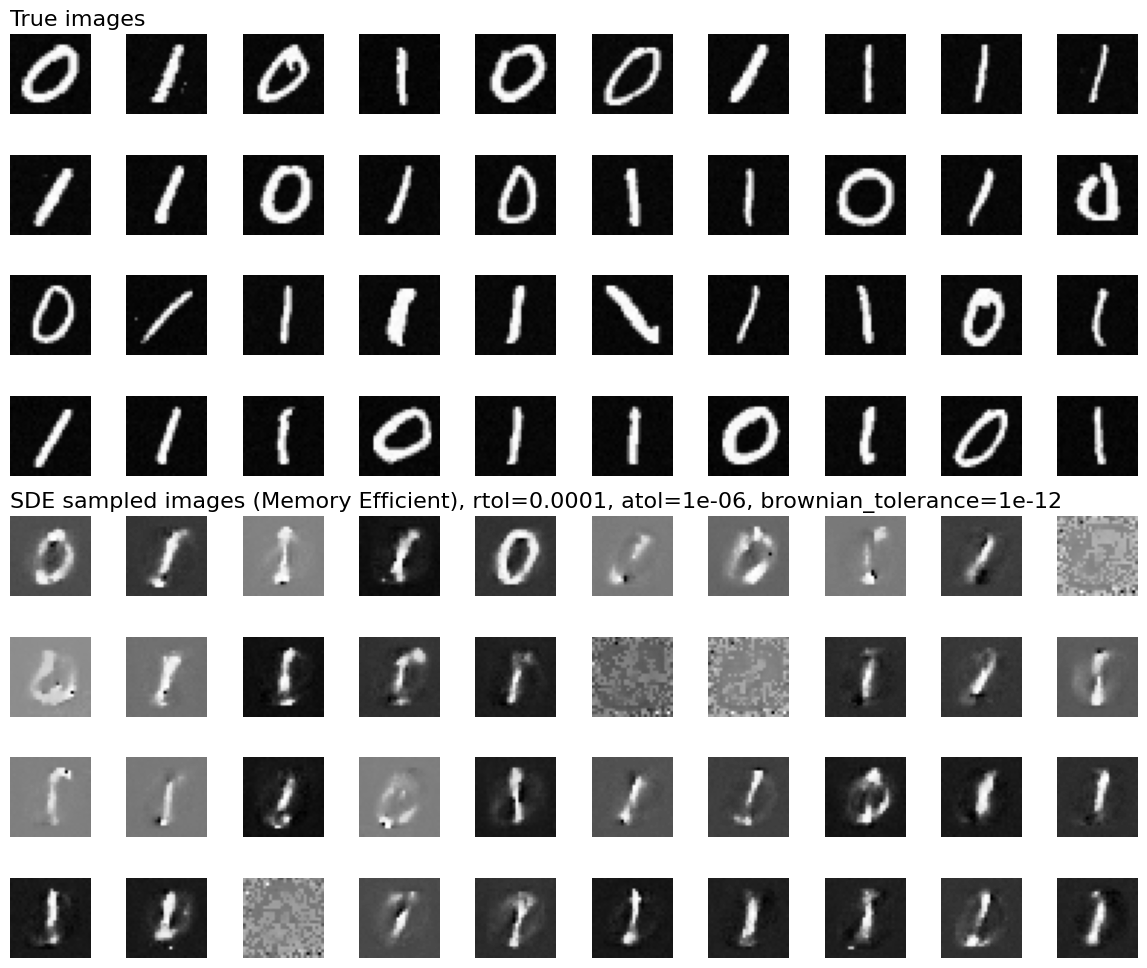

In [6]:
# Reshape true images
images_true = np.array(images_flat_true).reshape(-1, resolution[0], resolution[1])

num_examples = n_trajectories
n_rows = num_examples // 10  # number of rows per set

# Create grid: true images on top, generated images below
fig, axes = plt.subplots(2 * n_rows, 10, figsize=(15, 3 * n_rows))

# Plot true images in the first n_rows rows
for idx in range(num_examples):
    row = idx // 10
    col = idx % 10
    ax = axes[row, col]
    img = images_true[idx]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

# Plot SDE generated images in the next n_rows rows
for idx in range(num_examples):
    row = (idx // 10) + n_rows
    col = idx % 10
    ax = axes[row, col]
    img_generated = images_generated[idx]
    if img_generated.shape[-1] == 1:
        img_generated = img_generated.squeeze(-1)
    ax.imshow(img_generated, cmap='gray')
    ax.axis('off')

# Add titles
axes[0, 0].set_title('True images', loc='left', fontsize=16)
axes[n_rows, 0].set_title(
    f'SDE sampled images (Memory Efficient), rtol={rtol_sde}, atol={atol_sde}, '
    f'brownian_tolerance={brownian_tolerance}',
    loc='left', fontsize=16
)

plt.subplots_adjust(wspace=0.01, hspace=0.5)
plt.show()

## 6. Plot generated images only (clipped to [0, 1])

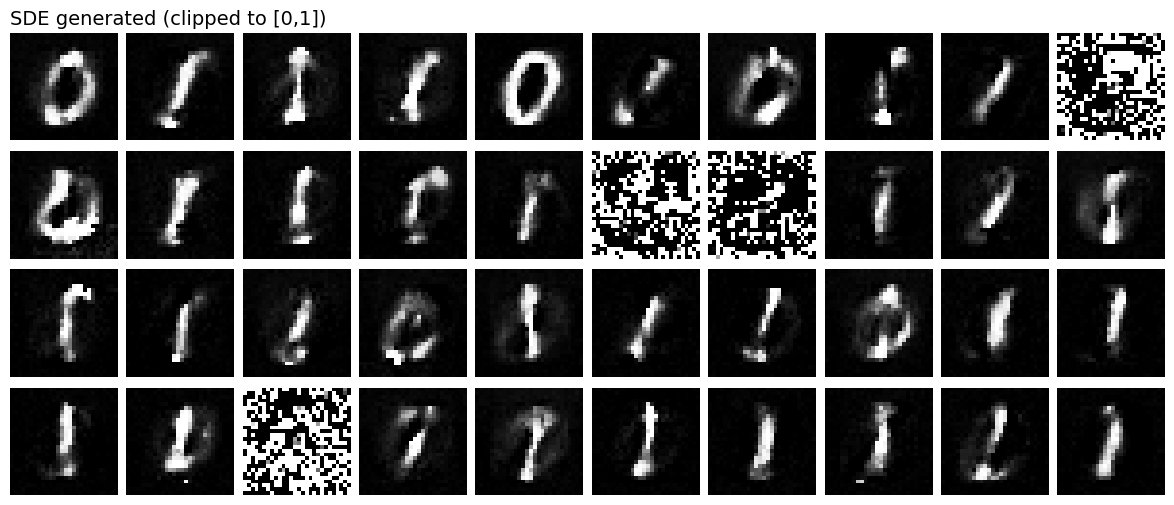

In [7]:
# Clipped version for cleaner visualization
images_generated_clipped = np.clip(images_generated, 0, 1)

fig, axes = plt.subplots(n_rows, 10, figsize=(15, 1.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing

for idx in range(num_examples):
    row = idx // 10
    col = idx % 10
    ax = axes[row, col]
    img = images_generated_clipped[idx]
    if img.shape[-1] == 1:
        img = img.squeeze(-1)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

axes[0, 0].set_title('SDE generated (clipped to [0,1])', loc='left', fontsize=14)
plt.subplots_adjust(wspace=0.01, hspace=0.1)
plt.show()